In [2]:
import pandas as pd
import numpy as np
rng = np.random.default_rng()
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.measure import block_reduce

#### Functions

In [81]:
def multivariate_lognormal_cascade(n, sigma1=1, sigma2=1, rho=0):
    mu1 = -1/2 * sigma1**2
    mu2 = -1/2 * sigma2**2

    PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),  np.array([[sigma1**2,corr*sigma1*sigma2], [corr*sigma1*sigma2, sigma2**2]]), 4))

    P = PQ[:,0].reshape(2,2)
    Q = PQ[:,1].reshape(2,2)
    for i in range(n):
        PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),np.array([[sigma1**2,rho*sigma1*sigma2], [rho*sigma1*sigma2, sigma2**2]]), P.shape[0]**2 * 4))
        P = np.kron(P, np.ones((2,2)))
        P = P * PQ[:,0].reshape(P.shape)
        Q = np.kron(Q, np.ones((2,2)))
        Q = Q * PQ[:,1].reshape(P.shape)

    P = P / np.sum(P)
    Q = Q / np.sum(Q)
    return(np.stack([P,Q], axis=-1))

def multiscale_estimation(pop):  
    c1_1s, c2_1s, c1_2s, c2_2s, rhos = [], [], [], [], []
    sizes = 2**np.arange(np.log2(lnc.shape[0])).astype(np.int32)
    for i in sizes:
        pop_reduce = block_reduce(pop, block_size = (i,i,1), func = np.sum)
        c1_1s.append(np.nanmean(np.log(pop_reduce[:,:,0]), ))
        c2_1s.append(np.nanvar(np.log(pop_reduce[:,:,0])))
        c1_2s.append(np.nanmean(np.log(pop_reduce[:,:,1])))
        c2_2s.append(np.nanvar(np.log(pop_reduce[:,:,1])))
        rhos.append(np.corrcoef(np.log(pop_reduce[:,:,0]).flatten(), np.log(pop_reduce[:,:,1]).flatten())[1,0])
    return(pd.DataFrame({'sizes': sizes, 'log_sizes' : np.log2(sizes), 'c1_1s' : c1_1s, 'c2_1s': c2_1s, 'c1_2s' : c1_2s, 'c2_2s': c2_2s, 'rhos': rhos}))

def multifractale_estimation(df):
    coefreg = (df.log_sizes - df.log_sizes.mean()) / np.sum((df.log_sizes - df.log_sizes.mean())**2)
    c1_1 = np.sum((df.c1_1s - np.mean(df.c1_1s)) * coefreg)
    c2_1 = -np.sum((df.c2_1s - np.mean(df.c2_1s)) * coefreg)
    c1_2 = np.sum((df.c1_2s - np.mean(df.c1_2s)) * coefreg)
    c2_2 = -np.sum((df.c2_2s - np.mean(df.c2_2s)) * coefreg)
    rho = df.rhos.mean()
    return({'c1_1':c1_1, 'c2_1' : c2_1, 'c1_2':c1_2, 'c2_2':c2_2, 'rho':rho  }) 
    

#### Analyzes

In [52]:
sizes = 2**np.arange(8) 
sigma1, sigma2, corr = 0.2, 0.4, 0.7

In [82]:
lnc = multivariate_lognormal_cascade(6, sigma1=sigma1, sigma2=sigma2, rho=corr)
scale_index = multiscale_estimation(lnc)
scale_index

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
0,1,0.0,-9.861209,0.312702,-10.254662,1.081169,0.722006
1,2,1.0,-8.459975,0.283188,-8.809345,0.963461,0.724360
2,4,2.0,-7.055652,0.247072,-7.350316,0.822153,0.729442
3,8,3.0,-5.649363,0.206952,-5.875938,0.644040,0.729217
4,16,4.0,-4.247505,0.178147,-4.410955,0.510314,0.753154
5,32,5.0,-2.837417,0.131192,-2.954400,0.362583,0.714529
6,64,6.0,-1.431112,0.092369,-1.489019,0.199909,0.718175


<Axes: xlabel='log_sizes', ylabel='c1_1s'>

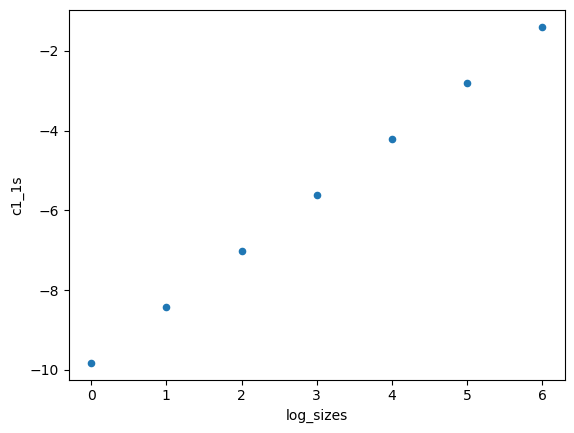

In [65]:
scale_index.plot.scatter('log_sizes', 'c1_1s')

In [58]:
df = scale_index.iloc[1:5]

In [68]:
multifractale_estimation(df)

{'c1_1': 1.405784754350601,
 'c2_1': 0.038822987805365375,
 'c1_2': 1.4663591541253869,
 'c2_2': 0.16136178465100304,
 'rho': 0.6953896340477612}

In [71]:
2*np.log(2) + sigma1**2/2

1.4062943611198906

In [72]:
paris = np.load('paris_household.npy')

#paris[paris==0] = 1
paris[:,:,0] = paris[:,:,0] / paris[:,:,0].sum() 
paris[:,:,1] = paris[:,:,1] / paris[:,:,1].sum() 

In [83]:
scale_index = multiscale_estimation(paris)
scale_index

C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_19688\1949108326.py:25: RuntimeWarning: divide by zero encountered in log
  c1_1s.append(np.nanmean(np.log(pop_reduce[:,:,0]), ))
C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_19688\1949108326.py:26: RuntimeWarning: divide by zero encountered in log
  c2_1s.append(np.nanvar(np.log(pop_reduce[:,:,0])))
C:\Users\francois.semecurbe\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)
C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_19688\1949108326.py:27: RuntimeWarning: divide by zero encountered in log
  c1_2s.append(np.nanmean(np.log(pop_reduce[:,:,1])))
C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_19688\1949108326.py:28: RuntimeWarning: divide by zero encountered in log
  c2_2s.append(np.nanvar(np.log(pop_reduce[:,:,1])))
C:\Users\francois.semecurbe\AppData\Loca

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
0,1,0.0,-inf,NaN,-inf,NaN,NaN
1,2,1.0,-inf,NaN,-inf,NaN,NaN
2,4,2.0,-inf,NaN,-inf,NaN,NaN
3,8,3.0,-inf,NaN,-inf,NaN,NaN
4,16,4.0,-4.536185,0.913454,-4.464685,0.648876,0.832144
5,32,5.0,-3.016669,0.500457,-2.986313,0.407596,0.816332
6,64,6.0,-1.440243,0.105662,-1.386724,0.000868,0.755216


In [80]:
0.4**0.5

0.6324555320336759